In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit


In [3]:
# len in meters
l = 0.02
b = 5e-3
d = 200e-6

g_a = 100e-6
g_d = 100e-6

# N / m**2
E = 98e9
# kg / m**3
rho = 8.5e3
v_upsilon = np.sqrt(E / rho)

# C_a = epsilon_0 * S / g_a

# m = rho * l * b * d

# F_0_theo = 1/2 * C_a * U**2 / g_a

ALPHA_N = [1.424987, 0.992249, 1.000198, 0.999994]

def get_alpha_n(n: int):
    if n > 3:
        return 1
    return ALPHA_N[n]

def calc_free_reed_eigenfrequency(n: int):
    alpha_n = get_alpha_n(n)
    nu = alpha_n * (2 * n + 1)**2 * np.pi * d * v_upsilon / (16 * np.sqrt(3) * l**2)
    return nu

target_freqs = [calc_free_reed_eigenfrequency(n) for n in range(4)]
print(target_freqs)
for i, freq in enumerate(target_freqs[1:]):
    print(f"nu_{i+1}/nu_0 = {freq / target_freqs[0]}")

target_freqs = target_freqs[:3]
lowest_harmonic = target_freqs[0]

[274.25448868690813, 1718.723524709954, 4812.478834467755, 9430.53467494007]
nu_1/nu_0 = 6.266892961128769
nu_2/nu_0 = 17.547493415729406
nu_3/nu_0 = 34.38607229399286


In [4]:
def lorentz_curve(f, f_0, omega_0, gamma):
    omega = 2 * np.pi * f
    return f_0 / np.sqrt((omega_0**2 - omega**2)**2 + gamma**2 * omega**2)

def phase_func(f, omega_0, gamma):
    omega = 2 * np.pi * f
    return np.arctan(gamma * omega / (omega_0**2 - omega**2))

In [5]:
import ast

def fit_analysis_lorentz(ax, freq, A, A_err):
    params, pcov = curve_fit(
        lorentz_curve,
        freq,
        A,
        p0=[0.002, 1, 1],
        sigma=A_err,
        absolute_sigma=True
    )
    params_err = np.sqrt(np.diag(pcov))

    xgrid = np.linspace(np.min(freq), np.max(freq), 300)
    ax.plot(xgrid, lorentz_curve(xgrid, *params))
    
    return params, params_err

def read_metadata(loc):
    with open(loc, "r") as file:
        return ast.literal_eval(file.readline())

def plot_target_freq(ax, target_freq: float):
    axes = ax.axis()
    ax.vlines(target_freq, -5, 5, colors="tab:grey", linestyles="--", label="Theoretical Peak")
    ax.axis(axes)

def read_exp_file(loc):
    freq, A, A_err, phi, phi_err = np.loadtxt(
        loc,
        delimiter=",",
        skiprows=2,
        unpack=True
    )
    metadata = read_metadata(loc)
    return (freq, A, A_err, phi, phi_err), metadata

def plot_freq_spectrum(fig, axs, data):
    (freq, A, A_err, phi, phi_err) = data
    freq, A, A_err, phi, phi_err = freq[1:], A[1:], A_err[1:], phi[1:], phi_err[1:]
    X = A * np.cos(phi)
    Y = A * np.sin(phi)

    ax1, ax2, ax3 = axs[0], axs[1], axs[2]
    ax1.errorbar(freq, A, yerr=A_err)
    ax1.set_xlabel(r"$\nu$ / Hz")
    ax1.set_ylabel(r"$A$ / Vpp")
    ax1.set_title("Resonance Curve (Amplitude)")

    # fit_analysis_lorentz(ax1, freq, A, A_err)
    
    ax2.errorbar(freq, phi, yerr=phi_err)
    ax2.set_xlabel(r"$\nu$ / Hz")
    ax2.set_ylabel(r"$\phi$")
    ax2.set_title("Phase Shift")

    ax3.errorbar(freq, X, label="$X = A \\cos (\\phi)$")
    ax3.errorbar(freq, Y, label="$Y = A \\sin (\\phi)$")
    ax3.set_xlabel(r"$\nu$ / Hz")
    ax3.set_ylabel(r"Amplitude / Vpp")
    ax3.set_title("Waveform Chart")
    ax3.legend()

    return fig, axs


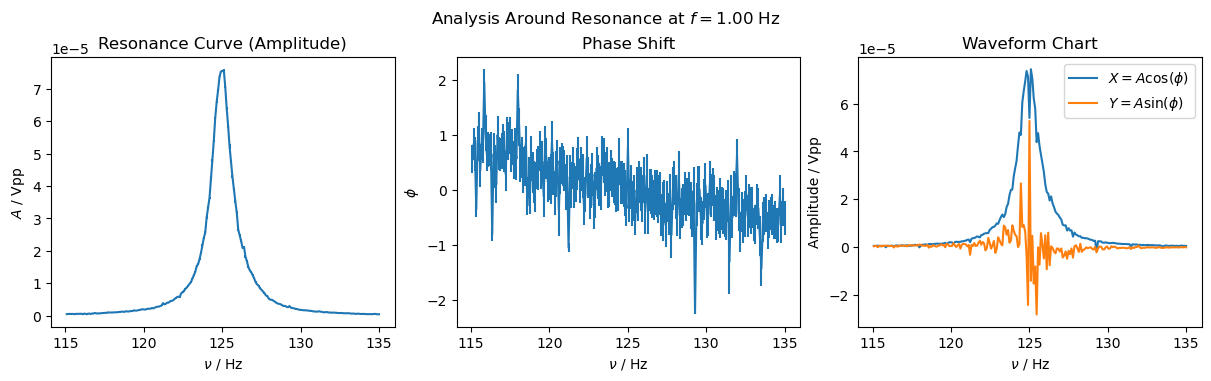

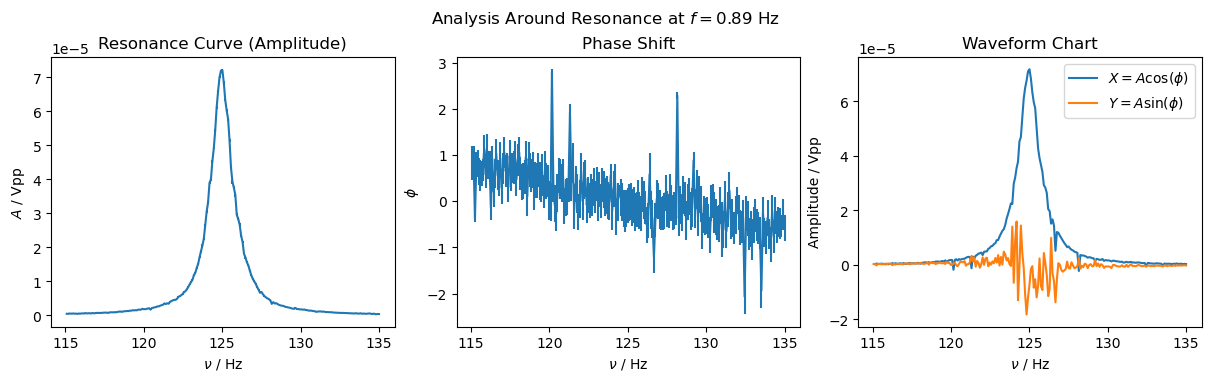

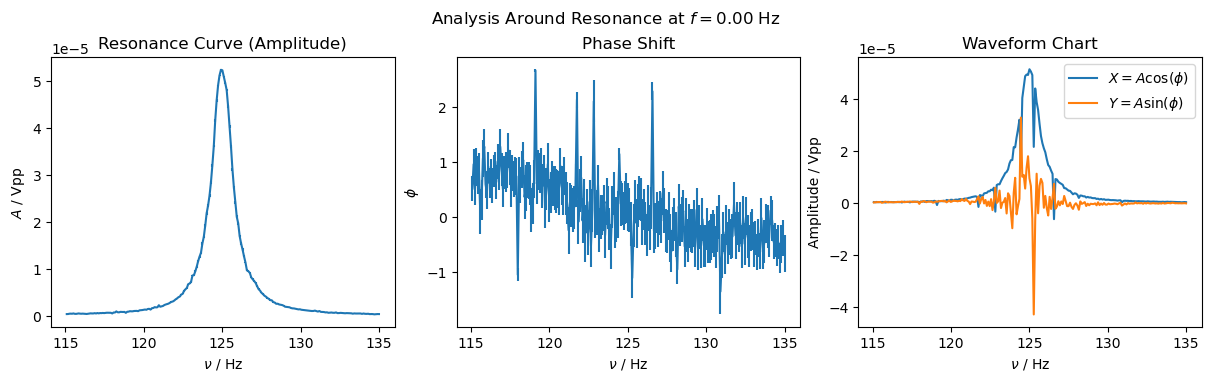

In [9]:
locs = [
    "Data/Night Measurement 3/voltage0_data_0713_135004.txt",
    "Data/Night Measurement 3/voltage1_data_0713_152824.txt",
    "Data/Night Measurement 3/voltage9_data_0714_020809.txt"
]

for i, loc in enumerate(locs):
    data, metadata = read_exp_file(loc)
    target_freq = metadata["target_voltage"]

    fig, axs = plt.subplots(1, 3, figsize=(4*3, 3.7), constrained_layout=True)
    plot_freq_spectrum(fig, axs, data)
    plot_target_freq(axs[0], target_freq)
    plot_target_freq(axs[1], target_freq)
    plot_target_freq(axs[2], target_freq)
    fig.suptitle(f"Analysis Around Resonance at $ f = {target_freq:.2f}$ Hz")
    plt.show()

## **Experiment B**

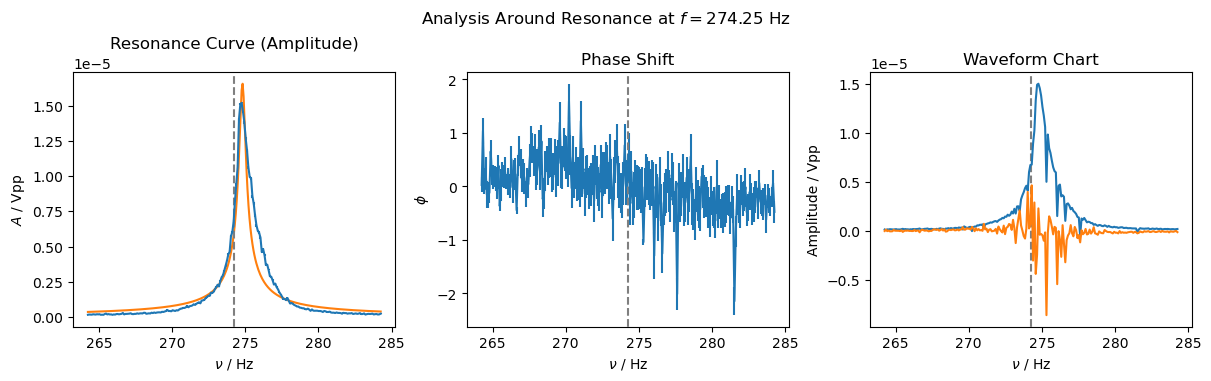

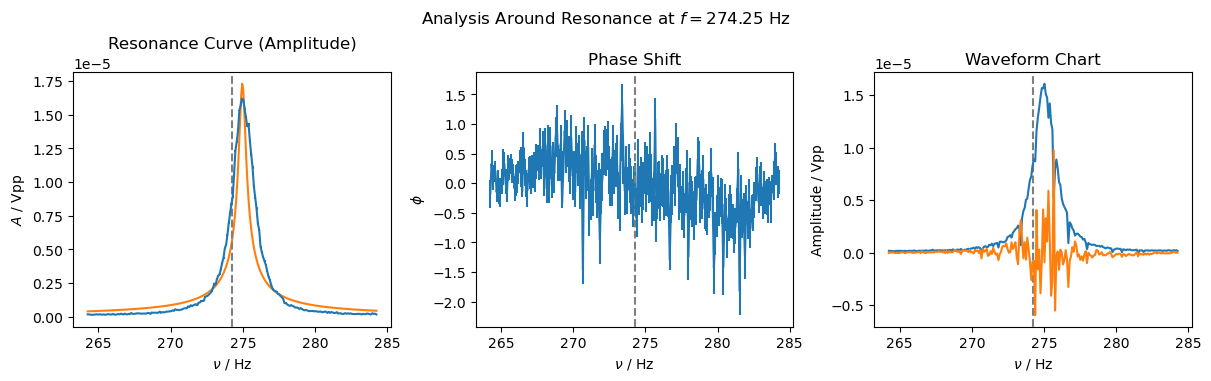

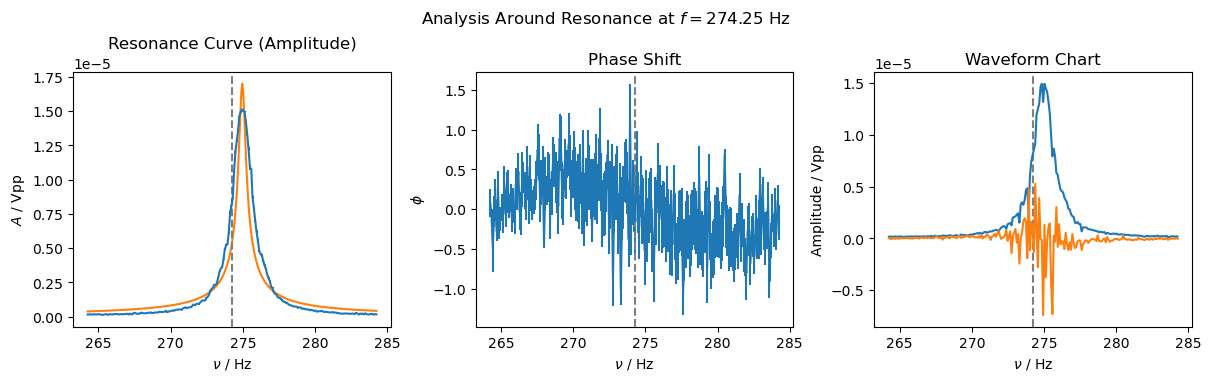

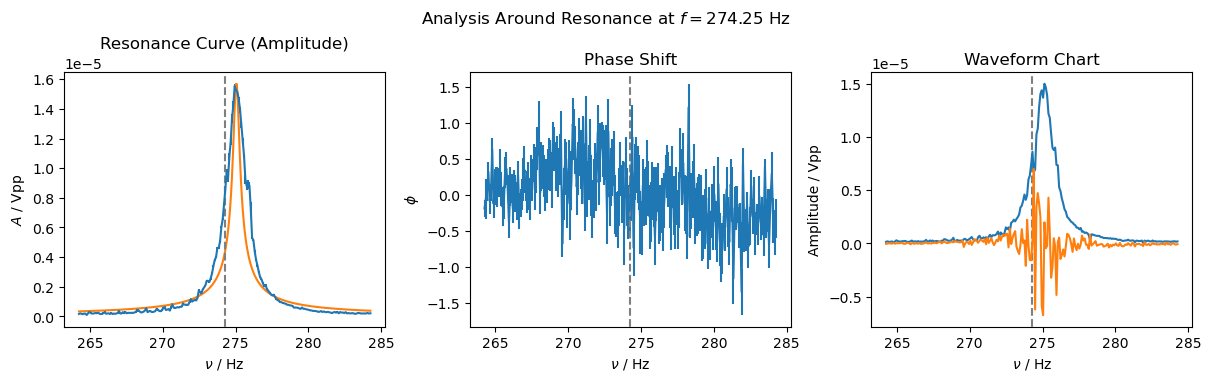

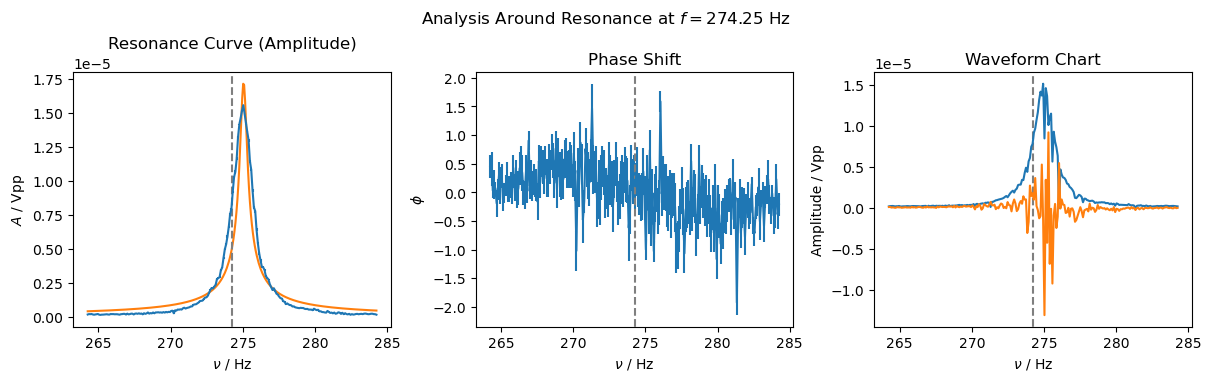

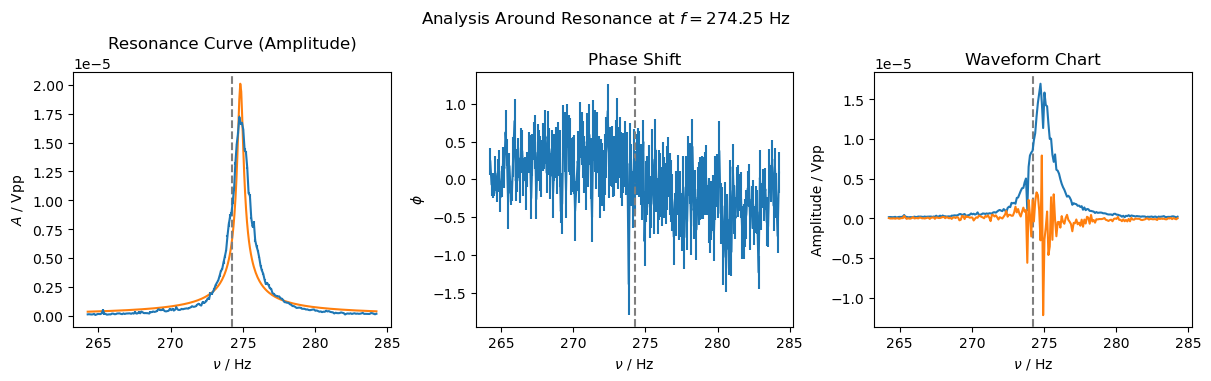

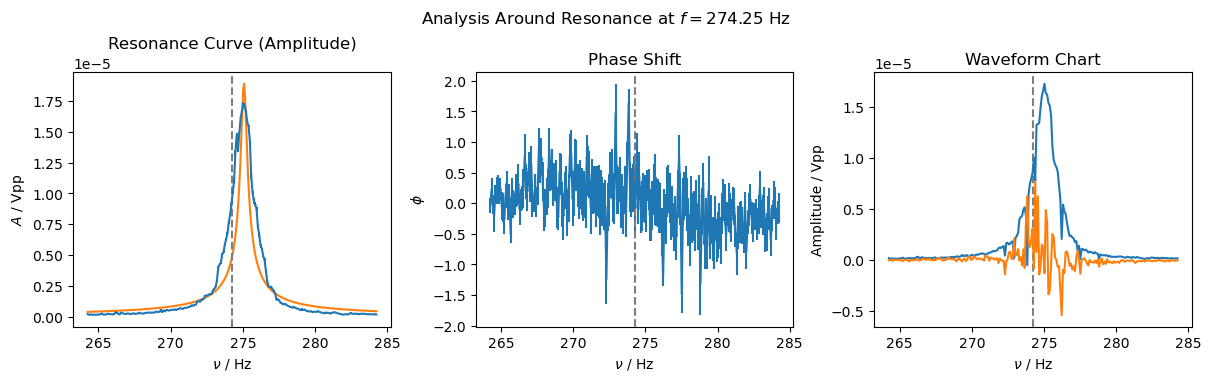

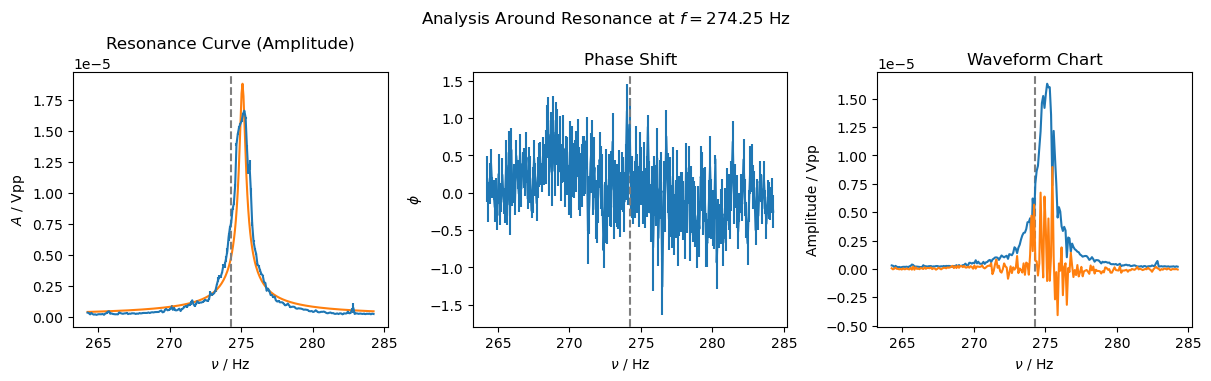

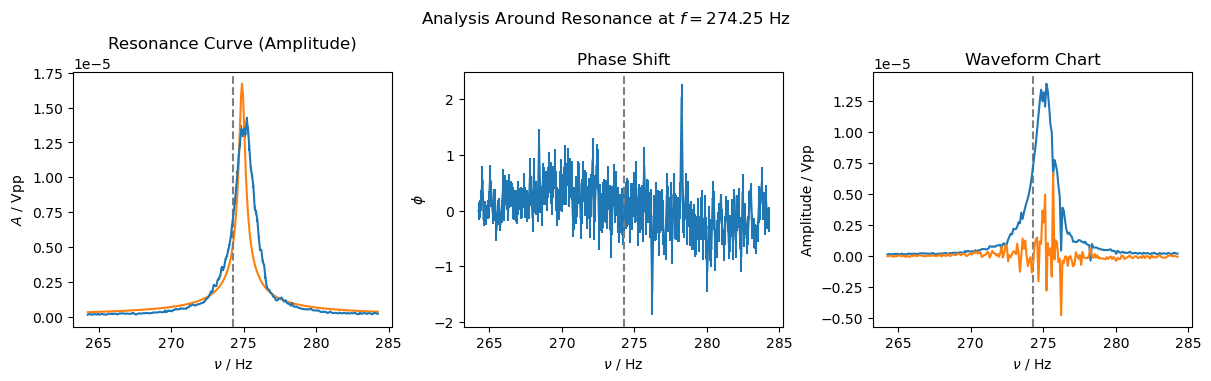

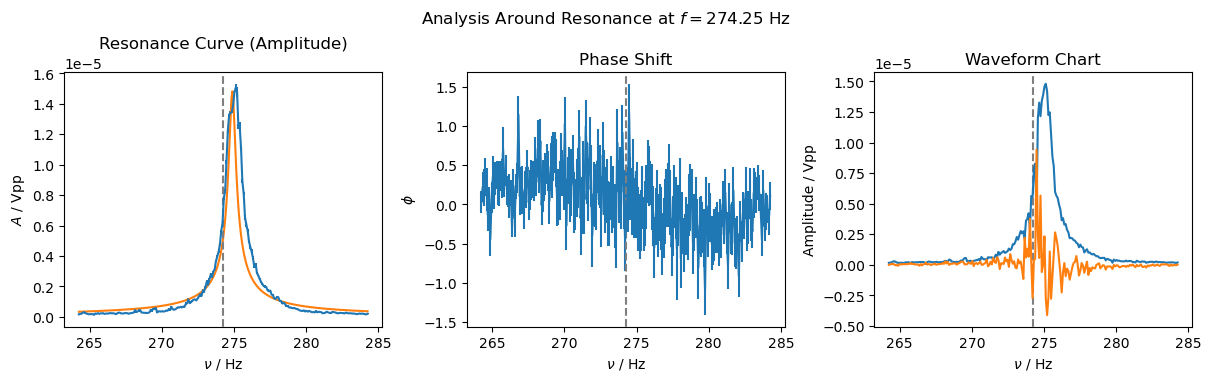

In [50]:
locs = [
    "temp0_data_0708_212553.txt",
    "temp1_data_0708_230411.txt",
    "temp2_data_0709_002229.txt",
    "temp3_data_0709_014047.txt",
    "temp4_data_0709_025905.txt",
    "temp5_data_0709_041723.txt",
    "temp6_data_0709_053541.txt",
    "temp8_data_0709_081217.txt",
    "temp7_data_0709_065359.txt",
    "temp9_data_0709_093035.txt",
]
path = "Data/Night Measurement/Experiment_B/"
locs = [path + loc for loc in locs]

for i, loc in enumerate(locs):
    data, metadata = read_exp_file(loc)

    fig, axs = plt.subplots(1, 3, figsize=(4*3, 3.7), constrained_layout=True)
    plot_freq_spectrum(fig, axs, data)
    plot_target_freq(axs[0], lowest_harmonic)
    plot_target_freq(axs[1], lowest_harmonic)
    plot_target_freq(axs[2], lowest_harmonic)
    fig.suptitle(f"Analysis Around Resonance at $ f = {lowest_harmonic:.2f}$ Hz")
    plt.show()

In [51]:
def find_maxima(data):
    (freq, A, A_err, phi, phi_err) = data

    i = np.argmax(A)
    return freq[i], A[i], A_err[i]

In [46]:
freqs = []
temps = []
for i, loc in enumerate(locs):
    data, metadata = read_exp_file(loc)

    freq, A, A_err = find_maxima(data)
    freqs.append(freq)
    temps.append(metadata["current_temp"])


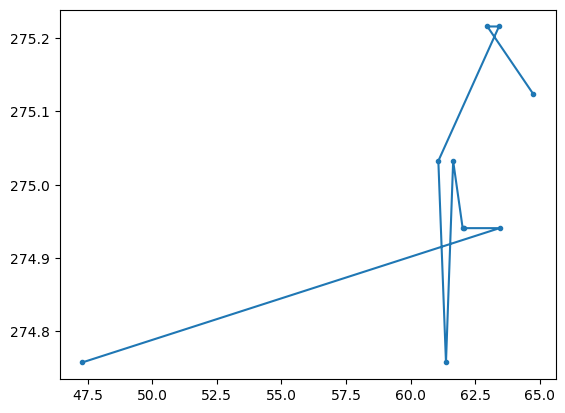

In [47]:
plt.plot(temps, freqs, marker=".")

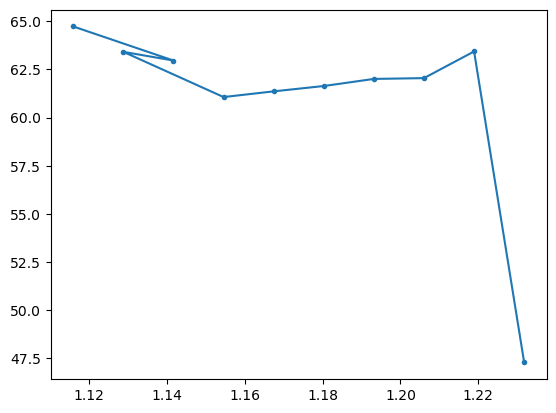

In [35]:
current_temps = []
target_voltage = []
for loc in locs:
    data, metadata = read_exp_file(loc)
    current_temps.append(metadata["current_temp"])
    target_voltage.append(calc_voltage_for_temp(metadata["target_temp"]))
    
    calc_voltage_for_temp(metadata["target_temp"])

plt.plot(target_voltage, current_temps, marker=".")

In [38]:
from Code.device_managers import illegal_calc_voltage_for_temp, calc_temp_for_voltage



In [ ]:
# fit functions for spectra
# calc chi square and p value
# plot residuals
# güte des resonators

# part b
# fit each spectrum (g.o.f.)
# resonance frequencies against temp plot
# linear regression fit
# slope = temp coeff
# vorzeichen der steigung

